# WP1.3 - Multi-phase power grids tests
This notebook demonstrates the operation of the multiconductor power flow with generic multi-phase power grids.
The proof is based on the tests defined in the WP1.3 specification document.
All results have been compared against openDSS to confirm their correctness.

Here the needed libraries and functions used for the tests are imported.

In [1]:
import multiconductor as mc
import multiconductor.test.testing_toolbox
import pandas as pd
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.float_format', '{:.12f}'.format) 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
grids = multiconductor.test.testing_toolbox.load_all_test_grids("wp1_3_multiphase")
l = []
for name, net in grids.items():
    mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)
    c = multiconductor.test.testing_toolbox.compare_to_dss(net)
    l.append(c)
pd.DataFrame(l, index=grids.keys()).sort_index(key=lambda x: x.str.len())

,max_vm_pu_diff,max_va_degree_diff,max_i_from_ka_diff,max_i_to_ka_diff,max_p_from_mw_diff,max_p_to_mw_diff,max_q_from_mvar_diff,max_q_to_mvar_diff
ieee_13_bus.pkl,0.000000262977,0.000002578167,0.000000578133,0.000000578137,0.000000767287,0.000000704027,0.000001377780,0.000001275440
three_bus_grid_3.pkl,0.000000000000,0.000000019367,0.000000002829,0.000000002829,0.000000000293,0.000000000293,0.000000000001,0.000000000000
three_bus_grid_1.pkl,0.000000000000,0.000000019368,0.000000002846,0.000000002846,0.000000000044,0.000000000044,0.000000000000,0.000000000000
three_bus_grid_2.pkl,0.000000000000,0.000000019367,0.000000005153,0.000000005153,0.000000000000,0.000000000000,0.000000000000,0.000000000000
five_bus_radial_variant_9.pkl,0.000000628123,0.000045731903,0.000000204603,0.000000204603,0.000000003525,0.000000003695,0.000000006073,0.000000004449
five_bus_radial_variant_8.pkl,0.000000625598,0.000167495665,0.000000200886,0.000000200886,0.000000003455,0.000000004058,0.000000006115,0.000000004362
five_bus_radial_variant_7.pkl,0.000000635228,0.000036562315,0.000000225997,0.000000225997,0.000000005132,0.000000004805,0.000000007192,0.000000003263
five_bus_radial_variant_6.pkl,0.000000301124,0.000018189038,0.000000055581,0.000000055581,0.000000000910,0.000000000739,0.000000002807,0.000000002208
five_bus_radial_variant_5.pkl,0.000000308377,0.000013062657,0.000000058776,0.000000058776,0.000000001252,0.000000001065,0.000000003322,0.000000002669
five_bus_radial_variant_4.pkl,0.000000303520,0.000091246270,0.000000057588,0.000000057588,0.000000001204,0.000000001024,0.000000002879,0.000000002249


## Tests on 3-bus grid
These tests serve to demonstrate the correct operation of grids with the neutral conductor and different grounding options, using the simplest possible grid configuration. The following scheme shows the general grid topology, here for grounding at bus 1 and 2. The neutral terminals of non-grounded buses are connected with the grounded neutral at the previous or following bus by a neutral conductor. 

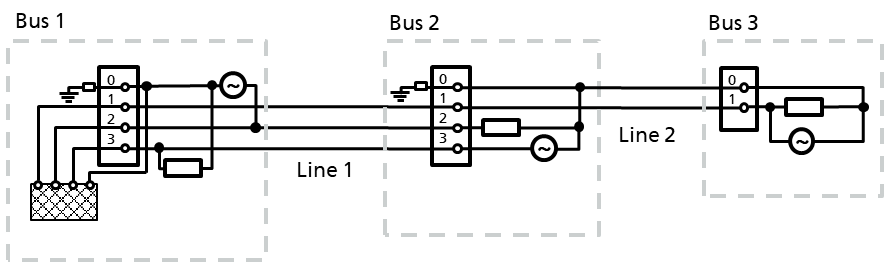


### 3-bus grid - grounding at bus 1 and 2, neutral between 2 and 3

In [3]:
# Select grid
variant = 1
net = grids[f"three_bus_grid_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 2.6867397195928788e-14
Max overall va_degree difference: 1.9367895082861297e-08
Max overall i_from_ka difference: 2.8464830770236205e-09
Max overall i_to_ka difference: 2.8464830770236205e-09
Max overall p_from_mw difference: 4.444372647682826e-11
Max overall p_to_mw difference: 4.4422354683604226e-11
Max overall q_from_mvar difference: 8.956899078763764e-14
Max overall q_to_mvar difference: 9.425260367981859e-14

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000002163 0.000000002163  106.102113834431  106.102113842128
      1     1.000000000000 1.000000000000   -0.000000000000    0.000000019367
      2     1.000000000000 1.000000000000 -120.000000000000 -119.999999987089
      3     1.000000000000 1.000000000000  120.000000000000  120.000000006456
1     0     0.000000001824 0.000000001824  -85.301059049503  -85.3010590

### 3-bus grid - grounding at bus 2 and 3, neutral between 1 and 2

In [4]:
# Select grid
variant = 2
net = grids[f"three_bus_grid_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 2.577148563998044e-14
Max overall va_degree difference: 1.9366771856349496e-08
Max overall i_from_ka difference: 5.153110882449852e-09
Max overall i_to_ka difference: 5.153110882449852e-09
Max overall p_from_mw difference: 8.568146192544646e-14
Max overall p_to_mw difference: 8.566758413763864e-14
Max overall q_from_mvar difference: 1.6408093416950265e-13
Max overall q_to_mvar difference: 1.6408499455785142e-13

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.001577028353 0.001577028353 -179.891602597678 -179.891602589979
      1     1.000000000000 1.000000000000   -0.000000000000    0.000000019367
      2     1.000000000000 1.000000000000 -120.000000000000 -119.999999987089
      3     1.000000000000 1.000000000000  120.000000000000  120.000000006456
1     0     0.000000000795 0.000000000795  160.615793770829  160.615793778

### 3-bus grid - grounding at bus 1 and 3, neutral between 2 and 1

In [5]:
# Select grid
variant = 3
net = grids[f"three_bus_grid_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 1.7408297026122455e-13
Max overall va_degree difference: 1.9367100201339582e-08
Max overall i_from_ka difference: 2.829113041058484e-09
Max overall i_to_ka difference: 2.829113041058484e-09
Max overall p_from_mw difference: 2.928878806152113e-10
Max overall p_to_mw difference: 2.9299324078024824e-10
Max overall q_from_mvar difference: 8.377832932601748e-13
Max overall q_to_mvar difference: 4.69017592775664e-13

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000001351 0.000000001351  120.001979238545  120.001979237063
      1     1.000000000000 1.000000000000   -0.000000000000    0.000000019367
      2     1.000000000000 1.000000000000 -120.000000000000 -119.999999987089
      3     1.000000000000 1.000000000000  120.000000000000  120.000000006456
1     0     0.000663638367 0.000663638367  -20.700288728731  -20.7002886968

## Tests on 5-bus grid - radial

The following tests are used to demonstrate the correct operation of different types of load and sgen connections in a five-bus, radial multi-phase grid with different variations of phase-to-phase and single-phase lines, starting from the same base topology. The following scheme shows the general grid topology, without loads and generators.

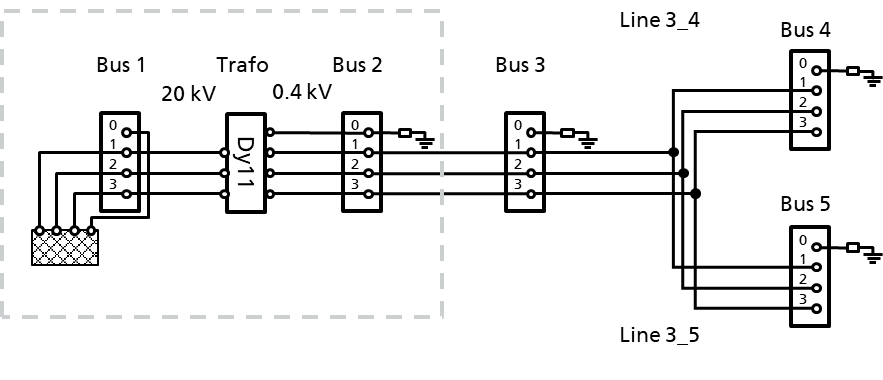

There are 10 variants according to the following table. "1ph" means a one phase plus neutral conductor line, "2ph" means a two phase plus neutral conductor line. For the buses, "p2p" means that loads and generators are connected phase to phase, while "p2n" means phase to neutral. Variants 1..6 use mixed phase to phase and phase to neutral connected loads and generators at Bus 3, while Variants 7..10 exclusively use phase to neutral loads and generators, as per the WP1.3 specification. 

| Variant | Line 3_4 | Line 3_5 | Bus 4 | Bus 5 |
| --- | --- | --- | --- | --- |
| 1 | 2ph| 2ph | p2p | p2p |
| 2 | 2ph| 2ph | p2n | p2p |
| 3 | 2ph| 2ph | p2n | p2n |
| 4 | 1ph| 2ph | p2n | p2n |
| 5 | 1ph| 2ph | p2n | p2p |
| 6 | 1ph| 1ph | p2n | p2n |
| 7 | 2ph| 2ph | p2n | p2n |
| 8 | 1ph| 2ph | p2n | p2n |
| 9 | 2ph| 1ph | p2n | p2n |
| 10 | 1ph| 1ph | p2n | p2n |


### 5-bus grid - radial - variant 1

In [6]:
# Select grid
variant = 1
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 4.6682804843989345e-08
Max overall va_degree difference: 6.445653298214893e-06
Max overall i_from_ka difference: 2.7592694032407827e-09
Max overall i_to_ka difference: 2.7592694032407827e-09
Max overall p_from_mw difference: 3.8584953461484606e-10
Max overall p_to_mw difference: 3.8632054586568154e-10
Max overall q_from_mvar difference: 6.341792863420737e-10
Max overall q_to_mvar difference: 6.259348551626576e-10

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000001248 1.000000001314    0.000000020131    0.000000039593
      2     1.000000000127 1.000000000193 -120.000000185977 -120.000000172971
      3     0.999999997572 0.999999997638  119.999999972701  119.999999979251
1     0     0.000000000000 0.000000000000  -26.565051177078   30.3557951

### 5-bus grid - radial - variant 2

In [7]:
# Select grid
variant = 2
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 3.1296748381759443e-07
Max overall va_degree difference: 1.1365634563276217e-05
Max overall i_from_ka difference: 6.715301861803802e-08
Max overall i_to_ka difference: 6.715301861803802e-08
Max overall p_from_mw difference: 1.7667362295359368e-09
Max overall p_to_mw difference: 1.563170357044008e-09
Max overall q_from_mvar difference: 3.410795886612389e-09
Max overall q_to_mvar difference: 2.698315377559768e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000002392 1.000000002458   -0.000000338184   -0.000000318722
      2     0.999999997122 0.999999997188 -120.000000488397 -120.000000475391
      3     0.999999997486 0.999999997552  119.999999848196  119.999999854747
1     0     0.000000000000 0.000000000000  -37.568592028827  -25.172567961

### 5-bus grid - radial - variant 3

In [8]:
# Select grid
variant = 3
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 3.0723415278544053e-07
Max overall va_degree difference: 3.043103947186765e-05
Max overall i_from_ka difference: 6.418031767152499e-08
Max overall i_to_ka difference: 6.418031767152499e-08
Max overall p_from_mw difference: 1.6908681260696667e-09
Max overall p_to_mw difference: 1.4949778290307414e-09
Max overall q_from_mvar difference: 2.6985443528186603e-09
Max overall q_to_mvar difference: 2.012928305809847e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000002458 1.000000002524   -0.000000464186   -0.000000444725
      2     0.999999996909 0.999999996975 -120.000000624631 -120.000000611625
      3     0.999999997258 0.999999997324  119.999999730901  119.999999737451
1     0     0.000000000000 0.000000000000  -14.036243467926  -42.44040378

### 5-bus grid - radial - variant 4

In [9]:
# Select grid
variant = 4
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 3.03520490407827e-07
Max overall va_degree difference: 9.124627013079589e-05
Max overall i_from_ka difference: 5.758846843839649e-08
Max overall i_to_ka difference: 5.758846843839649e-08
Max overall p_from_mw difference: 1.2040657221268347e-09
Max overall p_to_mw difference: 1.0239675496404033e-09
Max overall q_from_mvar difference: 2.8790964508307315e-09
Max overall q_to_mvar difference: 2.248752834985157e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000002232 1.000000002298   -0.000000460810   -0.000000441348
      2     0.999999995402 0.999999995468 -120.000000415713 -120.000000402707
      3     0.999999999499 0.999999999565  119.999999900678  119.999999907228
1     0     0.000000000000 0.000000000000    0.000000000000   -0.7800293336

### 5-bus grid - radial - variant 5

In [10]:
# Select grid
variant = 5
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 3.0837714259934756e-07
Max overall va_degree difference: 1.3062656904594405e-05
Max overall i_from_ka difference: 5.8775746686334784e-08
Max overall i_to_ka difference: 5.8775746686334784e-08
Max overall p_from_mw difference: 1.2517640049503065e-09
Max overall p_to_mw difference: 1.065307717040831e-09
Max overall q_from_mvar difference: 3.3216626966342533e-09
Max overall q_to_mvar difference: 2.6690656863490037e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000002235 1.000000002301   -0.000000332440   -0.000000312978
      2     0.999999995541 0.999999995607 -120.000000288973 -120.000000275967
      3     0.999999999545 0.999999999611  120.000000021441  120.000000027991
1     0     0.000000000000 0.000000000000  -26.565051177078   -3.98973

### 5-bus grid - radial - variant 6

In [11]:
# Select grid
variant = 6
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 3.011243794315277e-07
Max overall va_degree difference: 1.818903832884189e-05
Max overall i_from_ka difference: 5.55810800439982e-08
Max overall i_to_ka difference: 5.55810800439982e-08
Max overall p_from_mw difference: 9.102432488306e-10
Max overall p_to_mw difference: 7.39120646631175e-10
Max overall q_from_mvar difference: 2.806607665457178e-09
Max overall q_to_mvar difference: 2.2076785443150837e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000001877 1.000000001943   -0.000000456581   -0.000000437120
      2     0.999999993825 0.999999993891 -120.000000210444 -120.000000197438
      3     1.000000001572 1.000000001637  120.000000066021  120.000000072571
1     0     0.000000000000 0.000000000000 -106.699244233994   22.103600826495
    

### 5-bus grid - radial - variant 7

In [12]:
# Select grid
variant = 7
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 6.352282009292054e-07
Max overall va_degree difference: 3.656231461945936e-05
Max overall i_from_ka difference: 2.2599712778959002e-07
Max overall i_to_ka difference: 2.2599712778959002e-07
Max overall p_from_mw difference: 5.132337894953043e-09
Max overall p_to_mw difference: 4.804956682535888e-09
Max overall q_from_mvar difference: 7.192146678561273e-09
Max overall q_to_mvar difference: 3.262914672827466e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000002029 1.000000002095   -0.000001164151   -0.000001144689
      2     0.999999995863 0.999999995929 -120.000001507246 -120.000001494239
      3     0.999999993760 0.999999993826  119.999998970266  119.999998976817
1     0     0.000000000000 0.000000000000  -45.000000000000  -45.7266521530

### 5-bus grid - radial - variant 8

In [13]:
# Select grid
variant = 8
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 6.255980657954296e-07
Max overall va_degree difference: 0.00016749566466955912
Max overall i_from_ka difference: 2.00886026979763e-07
Max overall i_to_ka difference: 2.00886026979763e-07
Max overall p_from_mw difference: 3.4546082938735623e-09
Max overall p_to_mw difference: 4.057968627790842e-09
Max overall q_from_mvar difference: 6.114502128576338e-09
Max overall q_to_mvar difference: 4.362116726858156e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000001894 1.000000001960   -0.000001157201   -0.000001137738
      2     0.999999994603 0.999999994669 -120.000001288095 -120.000001275089
      3     0.999999996270 0.999999996336  119.999999139164  119.999999145714
1     0     0.000000000000 0.000000000000    0.000000000000   -3.323801420840

### 5-bus grid - radial - variant 9

In [14]:
# Select grid
variant = 9
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 6.281228921434234e-07
Max overall va_degree difference: 4.573190298629015e-05
Max overall i_from_ka difference: 2.0460264832378172e-07
Max overall i_to_ka difference: 2.0460264832378172e-07
Max overall p_from_mw difference: 3.525371425339152e-09
Max overall p_to_mw difference: 3.6946345982613593e-09
Max overall q_from_mvar difference: 6.0728722744984864e-09
Max overall q_to_mvar difference: 4.44910998841086e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000001754 1.000000001820   -0.000001157150   -0.000001137688
      2     0.999999994686 0.999999994752 -120.000001280417 -120.000001267410
      3     0.999999996357 0.999999996423  119.999999131915  119.999999138466
1     0     0.000000000000 0.000000000000    8.746162262555   -0.848944526

### 5-bus grid - radial - variant 10

In [15]:
# Select grid
variant = 10
net = grids[f"five_bus_radial_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 6.175666477092889e-07
Max overall va_degree difference: 3.3751017852523546e-05
Max overall i_from_ka difference: 1.8149013431001393e-07
Max overall i_to_ka difference: 1.8149013431001393e-07
Max overall p_from_mw difference: 7.31293602410088e-09
Max overall p_to_mw difference: 7.4205626504619815e-09
Max overall q_from_mvar difference: 6.876387828938513e-09
Max overall q_to_mvar difference: 6.179729667224465e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000001625 1.000000001691   -0.000001149563   -0.000001130100
      2     0.999999993260 0.999999993326 -120.000001073161 -120.000001060155
      3     0.999999998597 0.999999998663  119.999999303695  119.999999310246
1     0     0.000000000000 0.000000000000  -82.874983651098   19.960110465

### 5-bus grid - meshed - variant 1

The following tests are used to demonstrate the correct operation of different types of load and sgen connections in a five-bus, meshed multi-phase grid with different variations of phase-to-phase and single-phase lines. The topology and variant definition is the same as in the 5-bus grid radial test, except buses 4 and 5 are connected by an additional line, such as to close a mesh consisting of buses 3, 4, and 5. 

In [16]:
# Select grid
variant = 1
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 1.0728294297379648e-07
Max overall va_degree difference: 1.132730528397019e-05
Max overall i_from_ka difference: 2.165057724767827e-08
Max overall i_to_ka difference: 2.165057724767827e-08
Max overall p_from_mw difference: 9.80323048432874e-10
Max overall p_to_mw difference: 9.778091374784692e-10
Max overall q_from_mvar difference: 3.70630924562132e-09
Max overall q_to_mvar difference: 3.6006013830192085e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000005084 1.000000005150   -0.000000007497    0.000000011965
      2     0.999999997703 0.999999997769 -120.000000368578 -120.000000355572
      3     0.999999995936 0.999999996002  120.000000178181  120.000000184732
1     0     0.000000000000 0.000000000000  -94.975121371332   31.190704634659

### 5-bus grid - meshed - variant 2

In [17]:
# Select grid
variant = 2
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 3.689351260049989e-07
Max overall va_degree difference: 1.644777722376034e-05
Max overall i_from_ka difference: 8.146755767213243e-08
Max overall i_to_ka difference: 8.146755767213243e-08
Max overall p_from_mw difference: 1.9972130962941925e-09
Max overall p_to_mw difference: 1.9618401573412436e-09
Max overall q_from_mvar difference: 2.4729872559470234e-09
Max overall q_to_mvar difference: 2.349181967009617e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000006220 1.000000006286   -0.000000361997   -0.000000342535
      2     0.999999994801 0.999999994867 -120.000000670558 -120.000000657552
      3     0.999999995847 0.999999995913  120.000000050321  120.000000056871
1     0     0.000000000000 0.000000000000  -77.079249664168  -25.539595836

### 5-bus grid - meshed - variant 3

In [18]:
# Select grid
variant = 3
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 5.204332864661154e-07
Max overall va_degree difference: 1.6863738967032305e-05
Max overall i_from_ka difference: 1.7921494088746215e-07
Max overall i_to_ka difference: 1.7921494088746215e-07
Max overall p_from_mw difference: 5.31679776594185e-09
Max overall p_to_mw difference: 4.434359095195628e-09
Max overall q_from_mvar difference: 9.857690838957489e-09
Max overall q_to_mvar difference: 6.769155535581162e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000005657 1.000000005723   -0.000000530016   -0.000000510554
      2     0.999999993716 0.999999993782 -120.000000788789 -120.000000775783
      3     0.999999995775 0.999999995841  119.999999933122  119.999999939672
1     0     0.000000000000 0.000000000000  -99.036957870362  -38.4821603057

### 5-bus grid - meshed - variant 4

In [19]:
# Select grid
variant = 4
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 5.147950611350538e-07
Max overall va_degree difference: 1.6086621574373794e-05
Max overall i_from_ka difference: 1.7146696207337442e-07
Max overall i_to_ka difference: 1.7146696207337442e-07
Max overall p_from_mw difference: 4.13723148101619e-09
Max overall p_to_mw difference: 3.311926420612732e-09
Max overall q_from_mvar difference: 9.80940921026241e-09
Max overall q_to_mvar difference: 6.920841546555201e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000005438 1.000000005504   -0.000000522757   -0.000000503295
      2     0.999999992281 0.999999992347 -120.000000581080 -120.000000568074
      3     0.999999997978 0.999999998044  120.000000100908  120.000000107458
1     0     0.000000000000 0.000000000000   66.801409486352  -22.42705761365

### 5-bus grid - meshed - variant 5

In [20]:
# Select grid
variant = 5
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 3.6283487925281577e-07
Max overall va_degree difference: 1.7012116401815547e-05
Max overall i_from_ka difference: 7.175300473227786e-08
Max overall i_to_ka difference: 7.175300473227786e-08
Max overall p_from_mw difference: 2.896616887321235e-09
Max overall p_to_mw difference: 2.895133569512376e-09
Max overall q_from_mvar difference: 2.6232908241496933e-09
Max overall q_to_mvar difference: 2.572008554052596e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000006087 1.000000006153   -0.000000355634   -0.000000336173
      2     0.999999993222 0.999999993288 -120.000000472347 -120.000000459341
      3     0.999999997891 0.999999997957  120.000000224349  120.000000230899
1     0     0.000000000000 0.000000000000   71.565051177078   -3.496029597

### 5-bus grid - meshed - variant 6

In [21]:
# Select grid
variant = 6
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 5.082545977419528e-07
Max overall va_degree difference: 1.983608018463201e-05
Max overall i_from_ka difference: 1.4895843608586645e-07
Max overall i_to_ka difference: 1.4895843608586645e-07
Max overall p_from_mw difference: 3.2593039309136707e-09
Max overall p_to_mw difference: 2.484586071604955e-09
Max overall q_from_mvar difference: 9.338957412952098e-09
Max overall q_to_mvar difference: 6.6274449149125725e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000005254 1.000000005320   -0.000000515033   -0.000000495571
      2     0.999999990702 0.999999990768 -120.000000384193 -120.000000371187
      3     0.999999999955 1.000000000021  120.000000272446  120.000000278996
1     0     0.000000000000 0.000000000000   63.434948822922   -8.06185312

### 5-bus grid - meshed - variant 7

In [22]:
# Select grid
variant = 7
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 8.628236244367926e-07
Max overall va_degree difference: 3.337671517300578e-05
Max overall i_from_ka difference: 3.854603981001681e-07
Max overall i_to_ka difference: 3.854603981001681e-07
Max overall p_from_mw difference: 9.809189516207795e-09
Max overall p_to_mw difference: 9.67882544250509e-09
Max overall q_from_mvar difference: 1.4262742029091946e-08
Max overall q_to_mvar difference: 5.998298252627571e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000005207 1.000000005273   -0.000001241184   -0.000001221721
      2     0.999999992452 0.999999992518 -120.000001668725 -120.000001655718
      3     0.999999992367 0.999999992433  119.999999177954  119.999999184505
1     0     0.000000000000 0.000000000000 -102.528807709152  -41.004746197180

### 5-bus grid - meshed - variant 8

In [23]:
# Select grid
variant = 8
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 8.505378571443956e-07
Max overall va_degree difference: 3.229207250043942e-05
Max overall i_from_ka difference: 3.523158256246717e-07
Max overall i_to_ka difference: 3.523158256246717e-07
Max overall p_from_mw difference: 7.900118732806494e-09
Max overall p_to_mw difference: 8.22285955992541e-09
Max overall q_from_mvar difference: 1.2410205592339185e-08
Max overall q_to_mvar difference: 5.870944037346393e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000005082 1.000000005148   -0.000001229844   -0.000001210382
      2     0.999999991272 0.999999991338 -120.000001451121 -120.000001438114
      3     0.999999994832 0.999999994898  119.999999344758  119.999999351309
1     0     0.000000000000 0.000000000000   82.874983651098  -24.872615153790

### 5-bus grid - meshed - variant 9

In [24]:
# Select grid
variant = 9
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 8.510049174237366e-07
Max overall va_degree difference: 3.235722569527866e-05
Max overall i_from_ka difference: 3.53201447533813e-07
Max overall i_to_ka difference: 3.53201447533813e-07
Max overall p_from_mw difference: 7.892993307556662e-09
Max overall p_to_mw difference: 8.13291119172721e-09
Max overall q_from_mvar difference: 1.2427300582693035e-08
Max overall q_to_mvar difference: 5.897315351766769e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000005095 1.000000005161   -0.000001230360   -0.000001210897
      2     0.999999991266 0.999999991332 -120.000001451024 -120.000001438017
      3     0.999999994845 0.999999994911  119.999999345509  119.999999352060
1     0     0.000000000000 0.000000000000   57.994616791916  -24.740136185499
 

### 5-bus grid - meshed - variant 10

In [25]:
# Select grid
variant = 10
net = grids[f"five_bus_meshed_variant_{variant}.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 8.373016074925133e-07
Max overall va_degree difference: 3.803542473690413e-05
Max overall i_from_ka difference: 3.2193529070356774e-07
Max overall i_to_ka difference: 3.2193529070356774e-07
Max overall p_from_mw difference: 9.95599038974837e-09
Max overall p_to_mw difference: 1.2579529473644158e-08
Max overall q_from_mvar difference: 9.970824044885918e-09
Max overall q_to_mvar difference: 6.707094115342149e-09

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000000 0.000000000000    0.000000000000    0.000000000000
      1     1.000000004992 1.000000005058   -0.000001218383   -0.000001198921
      2     0.999999989929 0.999999989995 -120.000001245040 -120.000001232034
      3     0.999999997057 0.999999997123  119.999999515711  119.999999522261
1     0     0.000000000000 0.000000000000   79.380344723845  -10.4281407207

### IEEE 13 node feeder

The following test is used to demonstrate the correct operation of the multiconductor power flow for the common IEEE 13 node feeder multi-phase grid from PowerFactory.

In [27]:
# Select grid
net = grids["ieee_13_bus.pkl"]

# Load pp-multiconductor power flow
mc.run_pf(net, tol_vmag_pu=1e-9, tol_vang_rad=1e-9, MaxIter=100)

# Compare results
c = multiconductor.test.testing_toolbox.compare_to_dss(net)
multiconductor.test.testing_toolbox.print_comparison(c)
print()
print("bus results")
print(pd.merge(net.res_bus, net.res_bus_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[["vm_pu_mc", "vm_pu_dss", "va_degree_mc", "va_degree_dss"]])
print()
print("line results")
cols = [f"{c}{w}" for c in net.res_line_dss.columns for w in ["_mc", "_dss"]]
print(pd.merge(net.res_line, net.res_line_dss, left_index=True, right_index=True, suffixes=('_mc', '_dss'))[cols])

Max overall vm_pu difference: 2.629772992701618e-07
Max overall va_degree difference: 2.5781672507996234e-06
Max overall i_from_ka difference: 5.781329903697952e-07
Max overall i_to_ka difference: 5.78137033857562e-07
Max overall p_from_mw difference: 7.672870071528948e-07
Max overall p_to_mw difference: 7.040268196201183e-07
Max overall q_from_mvar difference: 1.3777795978553442e-06
Max overall q_to_mvar difference: 1.275440338482925e-06

bus results
                  vm_pu_mc      vm_pu_dss      va_degree_mc     va_degree_dss
index phase                                                                  
0     0     0.000000000010 0.000000000000   27.495668098134    0.000000000000
      1     0.999999999667 0.999999999667   -0.000000021539   -0.000000002173
      2     0.999999999768 0.999999999768 -120.000000017058 -120.000000004147
      3     0.999999999636 0.999999999636  119.999999976905  119.999999983360
1     0     0.000000000000 0.000000000000    0.000000000000    0.00000000000